# Neurosignature Framework Exploration

This notebook demonstrates the end-to-end pipeline for:
1. Generating synthetic recurrent dynamical systems
2. Driving them with Poisson synaptic-like inputs
3. Computing functional descriptors from outputs
4. Comparing systems using distance metrics
5. Visualizing descriptor space

Based on the design document in `design.md`.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from neurosignature.systems import ContinuousTimeRNN, SystemGenerator
from neurosignature.inputs import PoissonGenerator, SynapticKernel
from neurosignature.simulation import Simulator
from neurosignature.summaries import DescriptorAssembler
from neurosignature.metrics import euclidean_distance, cosine_distance
from neurosignature.experiments import SystemComparator
from neurosignature.visualization import plot_traces, plot_distance_matrix, compute_pca, plot_embedding

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Single System Demo

Generate one system and simulate its response to synaptic input.

In [8]:
# Parameters
N_S, N_H, N_C = 25, 64, 32
dt_ms = 1.0
duration_ms = 10000.0  # 10 seconds

# Generate system
system = ContinuousTimeRNN(
    n_hidden=N_H,
    n_inputs=N_S,
    n_outputs=N_C,
    spectral_radius=0.8,
    sparsity=0.1,
    seed=42
)

# Generate Poisson input
poisson_gen = PoissonGenerator(
    n_channels=N_S,
    lambda_max=100.0,
    seed=42
)
events = poisson_gen.generate_events(duration_ms=duration_ms, dt_ms=dt_ms)

# Convert to synaptic currents
synaptic_kernel = SynapticKernel(tau_s=10.0, dt_ms=dt_ms)
input_currents = synaptic_kernel.generate_input_currents(events, duration_ms=duration_ms)

print(f"Input shape: {input_currents.shape}")
print(f"Total events: {sum(len(e) for e in events)}")

Input shape: (10000, 25)
Total events: 987


C:\Users\MainUser\Documents\Repos\neurosignature\neurosignature\inputs\synaptic_kernel.py:40: RuntimeWarning: overflow encountered in exp
  alpha = t_norm * np.exp(-t_norm)
C:\Users\MainUser\Documents\Repos\neurosignature\neurosignature\inputs\synaptic_kernel.py:40: RuntimeWarning: overflow encountered in multiply
  alpha = t_norm * np.exp(-t_norm)


In [9]:
# Run simulation
simulator = Simulator(system, dt_ms=dt_ms)
outputs, states = simulator.run(input_currents, record_states=True)

print(f"Output shape: {outputs.shape}")
print(f"Output range: [{outputs.min():.3f}, {outputs.max():.3f}]")
print(f"State range: [{states.min():.3f}, {states.max():.3f}]")

Output shape: (10000, 32)
Output range: [-0.438, 0.373]
State range: [-0.496, 0.474]


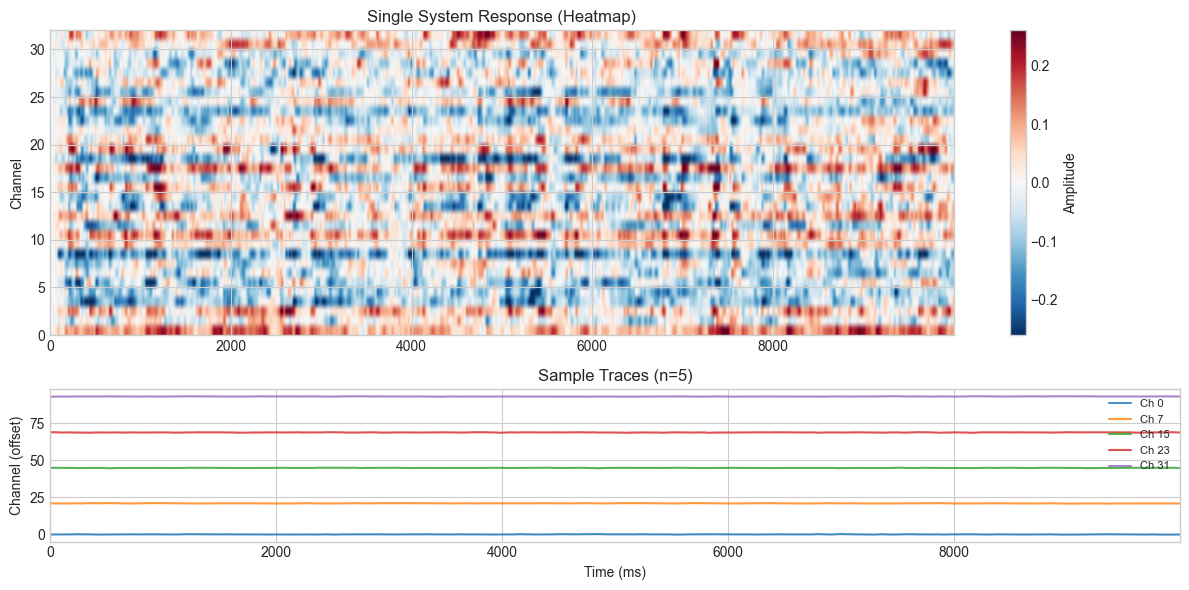

In [10]:
# Visualize traces
fig = plot_traces(outputs, dt_ms=dt_ms, title="Single System Response")
plt.show()

## 2. Compute Descriptors

Extract summary statistics from the output traces.

In [11]:
# Compute descriptor
assembler = DescriptorAssembler()
descriptor = assembler.compute_descriptor(outputs, dt_ms=dt_ms)

print(f"Descriptor dimension: {len(descriptor)}")
print(f"Descriptor range: [{descriptor.min():.3f}, {descriptor.max():.3f}]")

# Show descriptor info
info = assembler.get_descriptor_info(n_channels=N_C)
for key, value in info.items():
    print(f"{key}: {value}")

Descriptor dimension: 598
Descriptor range: [-0.526, 2450684.566]
basic_statistics_dim: 192
global_statistics_dim: 54
basic_total: 246
spectral_dim: 352
total_dim: 598


## 3. Compare Multiple Systems

Generate an ensemble of systems and compare their descriptors.

In [12]:
# Generate ensemble
generator = SystemGenerator(n_hidden=N_H, n_inputs=N_S, n_outputs=N_C)
n_systems = 20
systems = generator.generate_ensemble(n_systems=n_systems)

print(f"Generated {len(systems)} systems")

# Compare using same input
comparator = SystemComparator(simulator, assembler, dt_ms=dt_ms)
result = comparator.compare_with_shared_input(systems, input_currents)

print(f"Descriptors shape: {result['descriptors'].shape}")
print(f"Distance matrix shape: {result['distance_matrix'].shape}")
print(f"\nDistance statistics:")
for key, value in result['distance_statistics'].items():
    print(f"  {key}: {value:.3f}")

Generated 20 systems
Descriptors shape: (20, 598)
Distance matrix shape: (20, 20)

Distance statistics:
  mean: 5028101.619
  std: 3449795.104
  min: 1811215.355
  max: 15032828.174
  median: 4064235.400


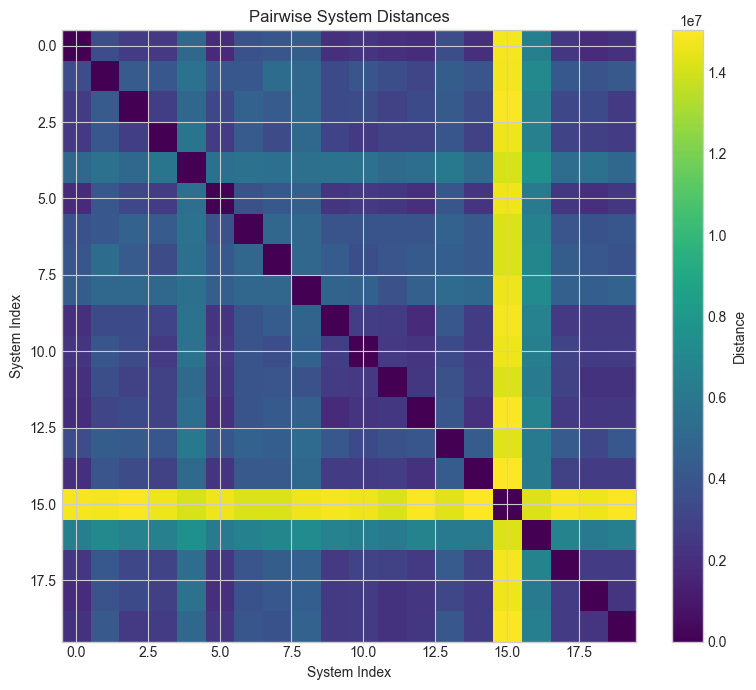

In [13]:
# Plot distance matrix
fig = plot_distance_matrix(result['distance_matrix'], title="Pairwise System Distances")
plt.show()

## 4. Descriptor Space Visualization

Use PCA to visualize the descriptor space.

Explained variance: [0.56711689 0.09818122]


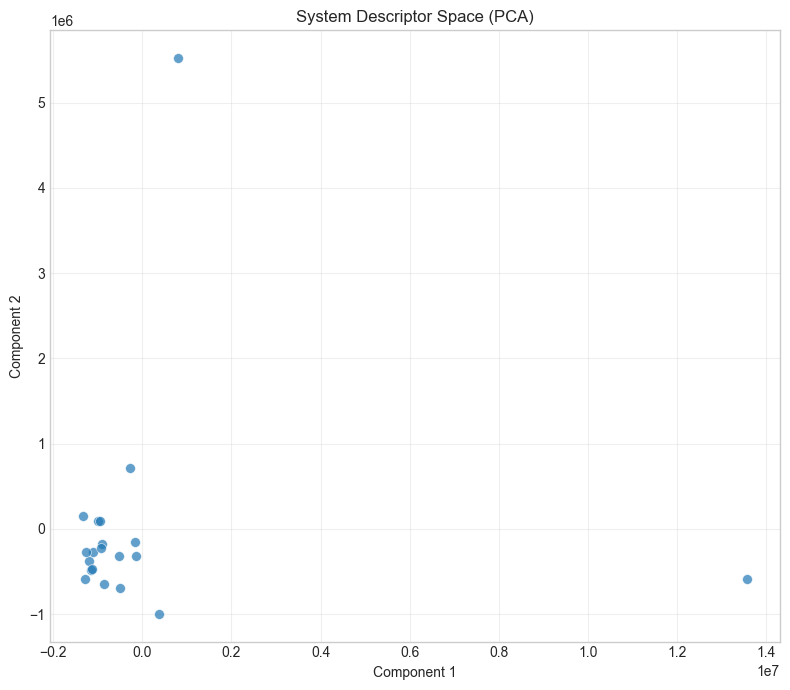

In [14]:
# Compute PCA embedding
descriptors = result['descriptors']
embedded, pca = compute_pca(descriptors, n_components=2)

print(f"Explained variance: {pca.explained_variance_ratio_}")

# Plot
fig = plot_embedding(embedded, title="System Descriptor Space (PCA)")
plt.show()

## 5. Parameter Sweep: Spectral Radius

Test how descriptors change with varying spectral radius.

In [15]:
from neurosignature.experiments import ParameterSweeper

# Sweep spectral radius
radii = [0.3, 0.5, 0.7, 0.8, 0.9]
sweeper = ParameterSweeper(generator, assembler, simulator)
sweep_result = sweeper.sweep_spectral_radius(radii, input_currents)

print(f"Sweep shape: {sweep_result['descriptors'].shape}")

Sweep shape: (5, 598)


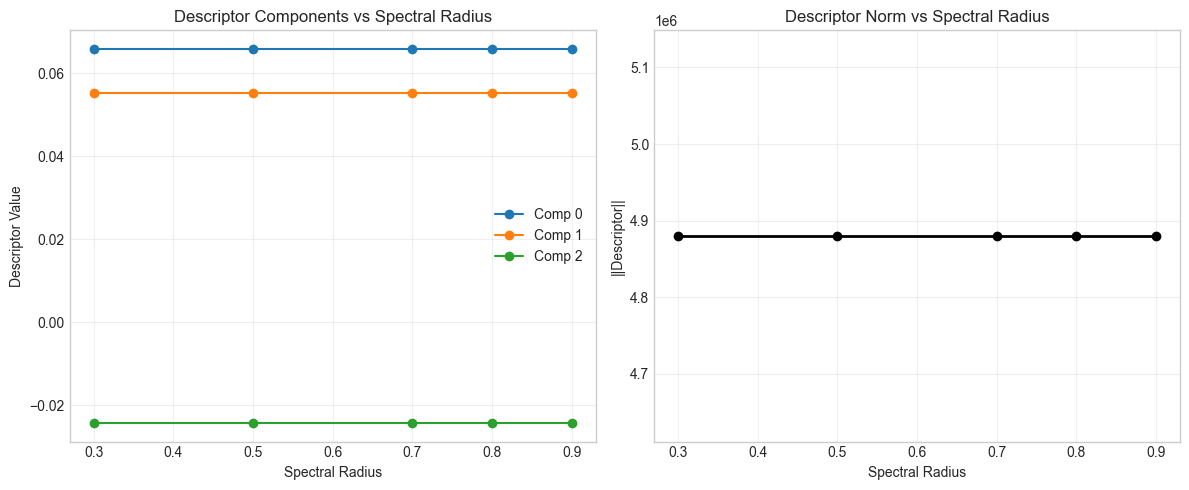

In [16]:
# Plot descriptor trajectory
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First few components
for i in range(min(3, sweep_result['descriptors'].shape[1])):
    axes[0].plot(radii, sweep_result['descriptors'][:, i], marker='o', label=f'Comp {i}')
axes[0].set_xlabel('Spectral Radius')
axes[0].set_ylabel('Descriptor Value')
axes[0].set_title('Descriptor Components vs Spectral Radius')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Norm
norms = np.linalg.norm(sweep_result['descriptors'], axis=1)
axes[1].plot(radii, norms, marker='o', color='black', linewidth=2)
axes[1].set_xlabel('Spectral Radius')
axes[1].set_ylabel('||Descriptor||')
axes[1].set_title('Descriptor Norm vs Spectral Radius')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Validation: Can Descriptors Distinguish System Types?

Compare sparse vs dense systems and check if they cluster separately.

In [17]:
# Generate two groups: sparse and dense
n_per_group = 10
sparse_systems = [
    generator.generate_random_system(sparsity=0.05, seed=200+i)
    for i in range(n_per_group)
]
dense_systems = [
    generator.generate_random_system(sparsity=0.5, seed=300+i)
    for i in range(n_per_group)
]

# Compare groups
comparison = comparator.compare_groups(
    sparse_systems, dense_systems, input_currents
)

print("Group Comparison:")
print(f"  Within sparse mean: {comparison['within_group_a_mean']:.3f}")
print(f"  Within dense mean: {comparison['within_group_b_mean']:.3f}")
print(f"  Between groups mean: {comparison['between_groups_mean']:.3f}")

# Check if between > within (good separation)
within_mean = (comparison['within_group_a_mean'] + comparison['within_group_b_mean']) / 2
separation = comparison['between_groups_mean'] / (within_mean + 1e-6)
print(f"\nSeparation ratio: {separation:.2f} (>1 means good separation)")

Group Comparison:
  Within sparse mean: 3322023.988
  Within dense mean: 4818416.027
  Between groups mean: 4130605.828

Separation ratio: 1.01 (>1 means good separation)


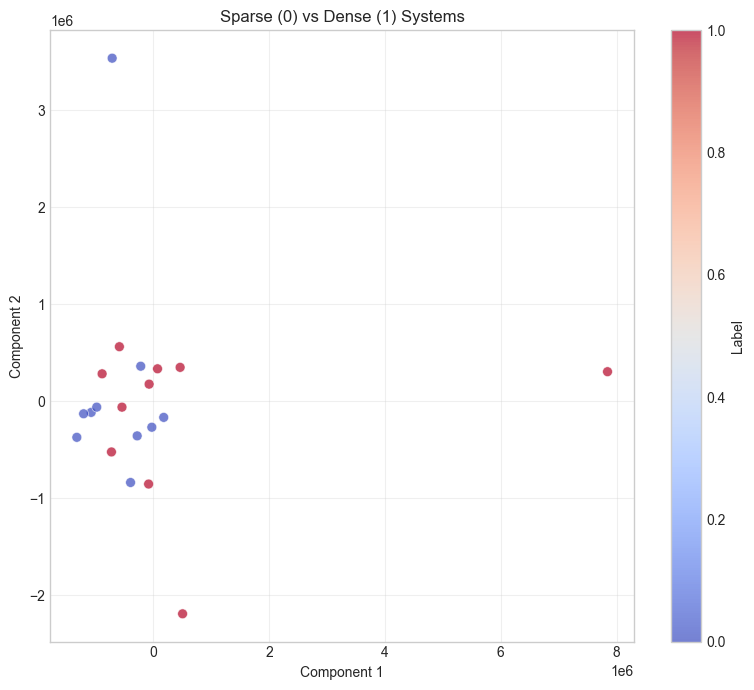

In [18]:
# Visualize with PCA, colored by group
all_descriptors = comparison['descriptors']
embedded, _ = compute_pca(all_descriptors, n_components=2)

# Labels: 0 for sparse, 1 for dense
labels = np.array([0]*n_per_group + [1]*n_per_group)

fig = plot_embedding(
    embedded,
    labels=labels,
    title="Sparse (0) vs Dense (1) Systems",
    cmap='coolwarm'
)
plt.show()

## Summary

This notebook demonstrated:

1. **System Generation**: Creating recurrent neural dynamical systems with controlled parameters
2. **Input Generation**: Master Poisson process with synaptic kernel filtering
3. **Simulation**: Euler integration of continuous-time dynamics
4. **Descriptors**: Computing summary statistics and spectral features
5. **Comparison**: Pairwise distances between systems
6. **Visualization**: PCA embedding shows clustering by system type

The framework successfully distinguishes systems with different sparsity levels, confirming the approach works as designed.